In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### Environmental constants
* rho = density of air
* g = acceleration from gravity

### Gear specifications
* L = characteristic length
* mu = flow speed
* Cd = drag coefficient
* m_gr = mass of projectile in grains (not grams)
* Cb = ballistic coefficient

### Initial conditions
* theta_0_deg = Initial angle of projectile in degrees
* v0 = Initial speed of projectile
* x0 = Initial horizontal position of projectile
* y0 = Initial vertical position of projectile

### Calculated constants
* A = bullet cross sectional area
* C = drag parameter
* theta_0 = Initial angle of projectile in radians
* vx0 = initial horizontal speed of projectile
* yx0 = initial vertical speed of projectile
* m = mass of projectile in kg

In [39]:
# Environmental constants
rho = 1.293
g = 9.82

# Gear specifications .22 hornet v-max
L = 5.6e-3 # L = 0.0254
mu = 1.989e-5
Cd = 0.5
m_gr = 35
Cb = 0.11
v0 = 945

# Initial conditions 
theta0_deg = 0
x0 = 0
y0 = 0

# Calculated constants
A = np.pi*L**2/4
theta0 = theta0_deg*np.pi/180
vx0 = v0*np.cos(theta0)
vy0 = v0*np.sin(theta0)
m = m_gr*6.479891e-5
# Cd = m/(Cb*A)
C = 0.5*Cd*rho*A

#### Investigate Reynolds number to check if approximations are valid
* If values are within interval defined by red lines, it is OK

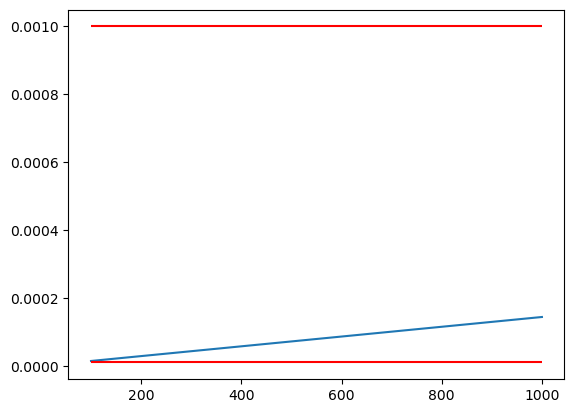

In [40]:
v = np.linspace(100, 1000, 50)
Re = rho*L*mu*v

plt.plot(v, Re)
plt.hlines(1e-3, xmin=100, xmax=1000, color='r')
plt.hlines(1e-5, xmin=100, xmax=1000, color='r')

### Dynamics calculations

Denote acceleration $\vec{a} = (a_x, a_y)$, velocity $\vec{v} = (v_x, v_y)$ and position $\vec{r} = (r_x, r_y)$
where $ \vec{a} = \frac{d\vec{v}}{dt}$ and  $ \vec{v} = \frac{d\vec{r}}{dt}.$

Newtons force equation
$ m\vec{a} = \vec{F} + m\vec{g} $
with standard drag force
$ \vec{F} = -C\hat{v}v² $
gives us
$$ \hat{x}: ma_x = -C\cos{(\theta(\vec{v}))}v² \qquad  \hat{y}: ma_y = -C\sin{(\theta(\vec{v}))}v²-mg $$
$$ \Leftrightarrow $$
$$ \hat{x}: a_x = -\frac{1}{m}C\cos{(\theta(\vec{v}))}v² \qquad  \hat{y}: a_y = -\frac{1}{m}(C\sin{(\theta(\vec{v}))}v²+mg) $$
Substituting
$ \cos{(\theta(\vec{v}))} = v_x/v \quad \textrm{and} \quad \sin{(\theta(\vec{v}))} = v_y/v $
we can express acceleration as
$$ \hat{x}: a_x = -\frac{1}{m}C v_x v \qquad  \hat{y}: a_y = -\frac{1}{m}(C v_y v + mg). $$
$\vec{a}$, $\vec{v}$ and $\vec{r}$ are related by
$$ \vec{v} = \vec{v_0} + \vec{a}t $$
$$ \vec{r} = \vec{r_0} + \vec{v_0}t + \frac{1}{2}\vec{a}t² $$
and
$$ v = \sqrt{v_x² + v_y²}. $$


### Algorithm
Splitting the above equations into components and discretizing time gives us
$$  \begin{align*}
    a_x(t_0) &= -\frac{C}{m}v_x(t_0)v(t_0) \\
    v_x(t_1) &= v_x(t_0) + a_x(t_0)\Delta t \\
    r_x(t_1) &= r_x(t_0) + v_x(t_0)\Delta t + \frac{1}{2}a_x(t_0)\Delta t² \end{align*}
$$
for *x*,
$$
    \begin{align*}
    a_y(t_0) &= -\frac{1}{m}(Cv_y(t_0)v(t_0) + mg) \\
    v_y(t_1) &= v_y(t_0) + a_y(t_0)\Delta t \\
    r_y(t_1) &= r_y(t_0) + v_y(t_0)\Delta t + \frac{1}{2}a_y(t_0)\Delta t² \end{align*}
$$
for *y* and
$$ \begin{align*}
    v_1 &= \sqrt{v_x(t_1)² + v_y(t_1)²}
    \end{align*} $$
for *v*.

Iterating one timestep we get
$$ \begin{align*}
    a_x(t_1) &= -\frac{C}{m}v_x(t_1)v(t_1) \\
    v_x(t_2) &= v_x(t_1) + a_x(t_1) \Delta t \\
    r_x(t_2) &= r_x(t_1) + v_x(t_1) \Delta t + \frac{1}{2}a_x(t_1) \Delta t²
    \end{align*} $$
and same pattern as above for *y*. We can generalize this as
$$ \begin{align*}
    a_x(t-1) &= -\frac{C}{m}v_x(t-1)v(t-1) \\
    v_x(t) &= v_x(t-1) + a_x(t-1)\Delta t \\
    r_x(t) &= r_x(t-1) + v_x(t-1)\Delta t + \frac{1}{2}a_x(t-1)\Delta t²
    \end{align*} $$
and again similar for *y*. The equation for *v* becomes
$$ \begin{align*}
    v(t) &= \sqrt{v_x(t)² + v_y(t)²}.
    \end{align*}
$$
This defines our algorithm.


### Pseudocode

Initialize timesteps *t* with spacing *dt*.

Initialize starting state for *a*, *v* and *r* in vectors.


for timesteps t do:

    let v = sqrt(v_x(t)² + v_y(t)²)

    let a_x(t) = -C/m * v_x(t) * v
    let a_y(t) = -C/m * v_y(t) * v - g

    let v_x(t+1) = v_x(t) + a_x(t) * dt
    let v_y(t+1) = v_y(t) + a_y(t) * dt

    let r_x(t+1) = r_x(t) + v_x(t) * dt + 1/2 * a_x(t) * dt²
    let r_y(t+1) = r_y(t) + v_y(t) * dt + 1/2 * a_y(t) * dt²



In [48]:
max_timesteps = 1000
dt = 0.001

timesteps = np.arange(0, max_timesteps)
r = {'x': np.zeros(max_timesteps), 'y': np.zeros(max_timesteps)}
v = {'x': np.zeros(max_timesteps), 'y': np.zeros(max_timesteps), 'v': np.zeros(max_timesteps)}
a = {'x': np.zeros(max_timesteps), 'y': np.zeros(max_timesteps)}

r['x'][0] = x0
r['y'][0] = y0
v['x'][0] = vx0
v['y'][0] = vy0

print("Running simulation with:")
print(f"x0={x0}, y0={y0}, vx0={vx0}, vy0={vy0}, theta0={theta0}")

for t in timesteps[:-1]:
    v['v'][t] = np.sqrt(v['x'][t]**2 + v['y'][t]**2)
    # print('v:', v['v'][t])

    a['x'][t] = -C/m*v['x'][t]*v['v'][t]
    a['y'][t] = -C/m*v['y'][t]*v['v'][t] - g
    # print('ax:', a['x'][t], 'ay:', a['y'][t])

    v['x'][t+1] = v['x'][t] + a['x'][t]*dt
    v['y'][t+1] = v['y'][t] + a['y'][t]*dt

    r['x'][t+1] = r['x'][t] + v['x'][t]*dt + 0.5*a['x'][t]*dt**2
    r['y'][t+1] = r['y'][t] + v['y'][t]*dt + 0.5*a['y'][t]*dt**2

timesteps = timesteps*dt
   

Running simulation with:
x0=0, y0=0, vx0=945.0, vy0=0.0, theta0=0.0


In [49]:
data = {
    'x': r['x'],
    'y': r['y'],
    'v': v['v'],
    't': timesteps
}
data = pd.DataFrame(data)

# data = data[data['x']<200]
print('length:', len(data))
data.head()

length: 1000


,x,y,v,t
0,0.000000,0.000000,945.000000,0.000
1,0.943433,-0.000005,941.865038,0.001
2,1.883740,-0.000020,938.750841,0.002
3,2.820944,-0.000044,935.657204,0.003
4,3.755065,-0.000078,932.583923,0.004


In [45]:
ref_data = pd.read_csv('22hornet-data.csv', sep='\t')

ref_data.rename(columns={ref_data.columns[0]: 'x', ref_data.columns[1]: 'y', ref_data.columns[2]: 'v', ref_data.columns[-1]: 't'}, inplace=True)
ref_data.drop(columns=[ref_data.columns[4]], inplace=True)

ref_data[ref_data.columns[-1]] = ref_data[ref_data.columns[-1]].apply(lambda x: x/1000)
ref_data = ref_data[ref_data['t']<data['t'].max()]

ref_data[ref_data.columns[0]] = ref_data[ref_data.columns[0]].apply(lambda x: x*0.9144)
ref_data[ref_data.columns[1]] = ref_data[ref_data.columns[1]].apply(lambda x: x*2.54)
ref_data[ref_data.columns[2]] = ref_data[ref_data.columns[2]].apply(lambda x: x*0.3048)


ref_data.head()

,x,y,v,Energy,t
0,0.0000,0.009398,944.2704,746,0.000
1,0.9144,0.065532,941.5272,741,0.001
2,1.8288,0.120904,938.7840,737,0.002
3,2.7432,0.175006,936.0408,733,0.003
4,3.6576,0.228346,933.6024,729,0.004


In [56]:
def compare_plot(data, ref_data, x, y):
    # Plot x vs t for the first dataframe
    plt.plot(data[x], data[y], label='my data', color='red')

    # Plot x vs t for the second dataframe
    plt.plot(ref_data[x], ref_data[y], label='ref data', color='blue')

    # Add labels and title
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"Comparison of {x} vs {y}")

    # Add a legend
    plt.legend()

    # Show the plot
    plt.show()

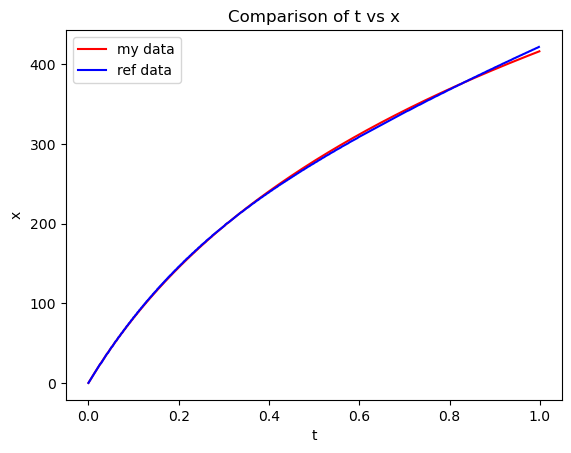

In [57]:
compare_plot(data, ref_data, 't', 'x')

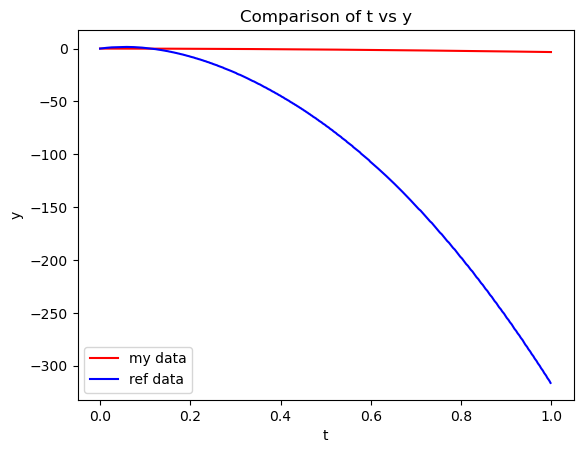

In [58]:
compare_plot(data, ref_data, 't', 'y')

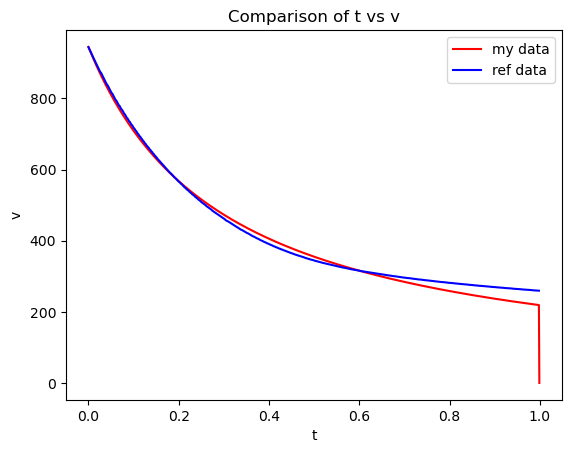

In [60]:
compare_plot(data, ref_data, 't', 'v')

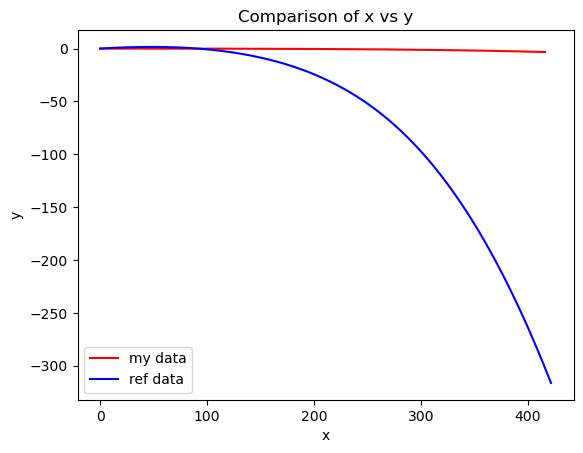

In [61]:
compare_plot(data, ref_data, 'x', 'y')